 **UCS547**

**Assignment III**:
**CUDA C++ Programming, Thrust Parallel Programming & RAPIDS**

**Name:Ajay Goyal**

**Roll No. 102303197**

# **Ques.1. Write a CUDA C/C++ program to perform element-wise addition of two vectors, C[i]=A[i]+B[i] Given: Vector size: N = 1024**

Steps performed:

1. Create vectors A and B on Host (CPU)
2. Allocate memory for A, B, and C on Device (GPU)
3. Copy input vectors from Host to Device
4. Launch CUDA kernel where each thread computes one element
5. Copy result vector C from Device back to Host
6. Display sample output to verify correctness

Each GPU thread computes one element using global thread ID.

In [1]:
%%writefile vector_add.cu
#include <stdio.h>
#include <cuda.h>

#define N 1024

__global__ void vectorAdd(int *A, int *B, int *C, int size)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if(i < size)
    {
        C[i] = A[i] + B[i];
    }
}

int main()
{
    int A[N], B[N], C[N];

    int *d_A, *d_B, *d_C;

    // Initialize vectors on Host
    for(int i = 0; i < N; i++)
    {
        A[i] = i;
        B[i] = i * 2;
    }

    // Allocate memory on Device
    cudaMalloc((void**)&d_A, N * sizeof(int));
    cudaMalloc((void**)&d_B, N * sizeof(int));
    cudaMalloc((void**)&d_C, N * sizeof(int));

    // Copy data from Host to Device
    cudaMemcpy(d_A, A, N * sizeof(int), cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, B, N * sizeof(int), cudaMemcpyHostToDevice);

    // Launch kernel
    int threadsPerBlock = 256;
    int blocksPerGrid = (N + threadsPerBlock - 1) / threadsPerBlock;

    vectorAdd<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C, N);

    cudaDeviceSynchronize();

    // Copy result back to Host
    cudaMemcpy(C, d_C, N * sizeof(int), cudaMemcpyDeviceToHost);

    // Print first 10 results
    printf("First 10 elements of Result Vector:\n");
    for(int i = 0; i < 10; i++)
    {
        printf("C[%d] = %d\n", i, C[i]);
    }

    // Free Device memory
    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}


Writing vector_add.cu


In [2]:
!nvcc -arch=sm_75 vector_add.cu -o vector_add
!./vector_add


First 10 elements of Result Vector:
C[0] = 0
C[1] = 3
C[2] = 6
C[3] = 9
C[4] = 12
C[5] = 15
C[6] = 18
C[7] = 21
C[8] = 24
C[9] = 27


# **2. Perform the same vector addition as in Q1 using Thrust library only.**

Steps performed:

1. Create host vectors A and B
2. Transfer data to device vectors using thrust::device_vector
3. Perform vector addition using thrust::transform()
4. Store result in device vector C
5. Copy result back to host
6. Display output

In [3]:
%%writefile thrust_vector_add.cu
#include <stdio.h>
#include <thrust/host_vector.h>
#include <thrust/device_vector.h>
#include <thrust/transform.h>
#include <thrust/copy.h>

#define N 1024

int main()
{
    // Step 1: Create host vectors
    thrust::host_vector<int> h_A(N);
    thrust::host_vector<int> h_B(N);

    // Initialize host vectors
    for(int i = 0; i < N; i++)
    {
        h_A[i] = i;
        h_B[i] = i * 2;
    }

    // Step 2: Copy data to device vectors
    thrust::device_vector<int> d_A = h_A;
    thrust::device_vector<int> d_B = h_B;
    thrust::device_vector<int> d_C(N);

    // Step 3: Perform vector addition using thrust::transform
    thrust::transform(d_A.begin(), d_A.end(),
                      d_B.begin(),
                      d_C.begin(),
                      thrust::plus<int>());

    // Step 4: Copy result back to host
    thrust::host_vector<int> h_C = d_C;

    // Step 5: Print first 10 results
    printf("First 10 elements of Result Vector using Thrust:\n");

    for(int i = 0; i < 10; i++)
    {
        printf("C[%d] = %d\n", i, h_C[i]);
    }

    return 0;
}


Writing thrust_vector_add.cu


In [4]:
!nvcc -arch=sm_75 thrust_vector_add.cu -o thrust_vector_add
!./thrust_vector_add


First 10 elements of Result Vector using Thrust:
C[0] = 0
C[1] = 3
C[2] = 6
C[3] = 9
C[4] = 12
C[5] = 15
C[6] = 18
C[7] = 21
C[8] = 24
C[9] = 27


#**3. Compute the dot product of two vectors of size, N =1024: Result=∑A[i]×B[i] using Thrust and compare its performance with that on CPU**

Steps performed:

1. Create host vectors A and B
2. Compute dot product using CPU
3. Copy vectors to GPU using thrust::device_vector
4. Compute dot product using thrust::inner_product()
5. Measure execution time of CPU and GPU
6. Compare performance


In [7]:
%%writefile thrust_dot_product.cu

#include <stdio.h>
#include <thrust/host_vector.h>
#include <thrust/device_vector.h>
#include <thrust/inner_product.h>
#include <chrono>

#define N 1024

using namespace std;
using namespace std::chrono;

int main()
{
    // Step 1: Create host vectors
    thrust::host_vector<int> h_A(N);
    thrust::host_vector<int> h_B(N);

    // Step 2: Initialize vectors
    for(int i = 0; i < N; i++)
    {
        h_A[i] = i;
        h_B[i] = i * 2;
    }

    auto cpu_start = high_resolution_clock::now();

    long long cpu_result = 0;

    for(int i = 0; i < N; i++)
    {
        cpu_result += (long long)h_A[i] * h_B[i];
    }

    auto cpu_end = high_resolution_clock::now();

    auto cpu_time = duration_cast<microseconds>(cpu_end - cpu_start);

    // Copy data to device
    thrust::device_vector<int> d_A = h_A;
    thrust::device_vector<int> d_B = h_B;

    auto gpu_start = high_resolution_clock::now();

    long long gpu_result = thrust::inner_product(
        d_A.begin(),
        d_A.end(),
        d_B.begin(),
        0LL
    );

    auto gpu_end = high_resolution_clock::now();

    auto gpu_time = duration_cast<microseconds>(gpu_end - gpu_start);

    printf("Dot Product using CPU = %lld\n", cpu_result);
    printf("CPU Execution Time = %lld microseconds\n\n",
           (long long)cpu_time.count());

    printf("Dot Product using GPU (Thrust) = %lld\n", gpu_result);
    printf("GPU Execution Time = %lld microseconds\n",
           (long long)gpu_time.count());

    return 0;
}



Overwriting thrust_dot_product.cu


In [8]:
!nvcc -arch=sm_75 thrust_dot_product.cu -o thrust_dot_product
!./thrust_dot_product


Dot Product using CPU = 714779648
CPU Execution Time = 80 microseconds

Dot Product using GPU (Thrust) = 714779648
GPU Execution Time = 650 microseconds


#**4. Write a CUDA kernel for matrix multiplication: C=A×B where Matrix size is 16 X 16. Explain why matrix multiplication needs more computation than addition (as in Q1).**

Steps performed:

1. Create matrices A and B on Host (CPU)
2. Allocate memory on Device (GPU)
3. Copy matrices from Host to Device
4. Launch CUDA kernel using 2D thread blocks
5. Each thread computes one element of matrix C
6. Copy result matrix back to Host
7. Display result

In [9]:
%%writefile matrix_multiplication.cu

#include <stdio.h>
#include <cuda.h>

#define N 16

__global__ void matrixMultiply(int *A, int *B, int *C)
{
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if(row < N && col < N)
    {
        int sum = 0;

        for(int k = 0; k < N; k++)
        {
            sum += A[row * N + k] * B[k * N + col];
        }

        C[row * N + col] = sum;
    }
}

int main()
{
    int A[N][N], B[N][N], C[N][N];

    int *d_A, *d_B, *d_C;

    // Initialize matrices
    for(int i = 0; i < N; i++)
    {
        for(int j = 0; j < N; j++)
        {
            A[i][j] = i + j;
            B[i][j] = i * j;
        }
    }

    // Allocate memory on GPU
    cudaMalloc((void**)&d_A, N*N*sizeof(int));
    cudaMalloc((void**)&d_B, N*N*sizeof(int));
    cudaMalloc((void**)&d_C, N*N*sizeof(int));

    // Copy matrices to GPU
    cudaMemcpy(d_A, A, N*N*sizeof(int), cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, B, N*N*sizeof(int), cudaMemcpyHostToDevice);

    // Define block and grid size
    dim3 threadsPerBlock(16,16);
    dim3 blocksPerGrid(1,1);

    // Launch kernel
    matrixMultiply<<<blocksPerGrid, threadsPerBlock>>>(d_A, d_B, d_C);

    cudaDeviceSynchronize();

    // Copy result back
    cudaMemcpy(C, d_C, N*N*sizeof(int), cudaMemcpyDeviceToHost);

    // Print result matrix
    printf("Result Matrix C:\n");

    for(int i = 0; i < N; i++)
    {
        for(int j = 0; j < N; j++)
        {
            printf("%4d ", C[i][j]);
        }
        printf("\n");
    }

    // Free GPU memory
    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}


Writing matrix_multiplication.cu


In [10]:
!nvcc -arch=sm_75 matrix_multiplication.cu -o matrix_multiplication
!./matrix_multiplication


Result Matrix C:
   0 1240 2480 3720 4960 6200 7440 8680 9920 11160 12400 13640 14880 16120 17360 18600 
   0 1360 2720 4080 5440 6800 8160 9520 10880 12240 13600 14960 16320 17680 19040 20400 
   0 1480 2960 4440 5920 7400 8880 10360 11840 13320 14800 16280 17760 19240 20720 22200 
   0 1600 3200 4800 6400 8000 9600 11200 12800 14400 16000 17600 19200 20800 22400 24000 
   0 1720 3440 5160 6880 8600 10320 12040 13760 15480 17200 18920 20640 22360 24080 25800 
   0 1840 3680 5520 7360 9200 11040 12880 14720 16560 18400 20240 22080 23920 25760 27600 
   0 1960 3920 5880 7840 9800 11760 13720 15680 17640 19600 21560 23520 25480 27440 29400 
   0 2080 4160 6240 8320 10400 12480 14560 16640 18720 20800 22880 24960 27040 29120 31200 
   0 2200 4400 6600 8800 11000 13200 15400 17600 19800 22000 24200 26400 28600 30800 33000 
   0 2320 4640 6960 9280 11600 13920 16240 18560 20880 23200 25520 27840 30160 32480 34800 
   0 2440 4880 7320 9760 12200 14640 17080 19520 21960 24400 26840 29280 3172

#**Ques.5. For vector addition of size 5,000,000, implement and compare**

• CPU sequential C/C++ program

• CUDA kernel implementation

• Thrust implementation

• RAPIDS implementation

Measure execution time and compare complexity for each approach and
present results in a table. Plot comparison graph

In [11]:
%%writefile cpu_vector_add.cu

#include <stdio.h>
#include <chrono>

#define N 5000000

using namespace std;
using namespace std::chrono;

int main()
{
    int *A = new int[N];
    int *B = new int[N];
    int *C = new int[N];

    for(int i = 0; i < N; i++)
    {
        A[i] = i;
        B[i] = i * 2;
    }

    auto start = high_resolution_clock::now();

    for(int i = 0; i < N; i++)
    {
        C[i] = A[i] + B[i];
    }

    auto end = high_resolution_clock::now();

    auto duration = duration_cast<milliseconds>(end - start);

    printf("CPU Time = %lld ms\n", (long long)duration.count());

    delete[] A;
    delete[] B;
    delete[] C;

    return 0;
}


Writing cpu_vector_add.cu


In [12]:
!nvcc -arch=sm_75 cpu_vector_add.cu -o cpu_vector_add
!./cpu_vector_add


CPU Time = 21 ms


In [22]:
%%writefile cuda_vector_add.cu

#include <stdio.h>
#include <cuda.h>

#define N 5000000

__global__ void vectorAdd(int *A, int *B, int *C)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if(i < N)
        C[i] = A[i] + B[i];
}

int main()
{
    int *A, *B, *C;
    int *d_A, *d_B, *d_C;

    size_t size = N * sizeof(int);

    // Allocate host memory
    A = (int*)malloc(size);
    B = (int*)malloc(size);
    C = (int*)malloc(size);

    // Initialize host arrays
    for(int i = 0; i < N; i++)
    {
        A[i] = i;
        B[i] = i * 2;
    }

    // Allocate device memory
    cudaMalloc(&d_A, size);
    cudaMalloc(&d_B, size);
    cudaMalloc(&d_C, size);

    // Copy data to GPU
    cudaMemcpy(d_A, A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, B, size, cudaMemcpyHostToDevice);

    cudaEvent_t start, stop;

    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);

    // Launch kernel
    vectorAdd<<<(N+255)/256, 256>>>(d_A, d_B, d_C);

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float milliseconds = 0;

    cudaEventElapsedTime(&milliseconds, start, stop);

    // Copy result back
    cudaMemcpy(C, d_C, size, cudaMemcpyDeviceToHost);

    printf("CUDA Kernel Time = %f ms\n", milliseconds);

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    free(A);
    free(B);
    free(C);

    return 0;
}



Overwriting cuda_vector_add.cu


In [23]:
!nvcc -arch=sm_75 cuda_vector_add.cu -o cuda_vector_add
!./cuda_vector_add


CUDA Kernel Time = 0.270976 ms


In [24]:
%%writefile thrust_vector_add_large.cu

#include <stdio.h>
#include <thrust/device_vector.h>
#include <thrust/transform.h>
#include <cuda.h>

#define N 5000000

int main()
{
    // Create device vectors
    thrust::device_vector<int> A(N);
    thrust::device_vector<int> B(N);
    thrust::device_vector<int> C(N);

    // Initialize vectors
    for(int i = 0; i < N; i++)
    {
        A[i] = i;
        B[i] = i * 2;
    }


    cudaEvent_t start, stop;

    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);

    // Perform vector addition using Thrust
    thrust::transform(A.begin(), A.end(),
                      B.begin(),
                      C.begin(),
                      thrust::plus<int>());

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float milliseconds = 0;

    cudaEventElapsedTime(&milliseconds, start, stop);

    printf("Thrust Time = %f ms\n", milliseconds);

    return 0;
}


Overwriting thrust_vector_add_large.cu


In [25]:
!nvcc -arch=sm_75 thrust_vector_add_large.cu -o thrust_vector_add_large
!./thrust_vector_add_large


Thrust Time = 0.309248 ms


In [26]:
import cudf
import cupy as cp
import time

N = 5_000_000

A = cudf.Series(cp.arange(N))
B = cudf.Series(cp.arange(N)*2)

start = time.time()

C = A + B

end = time.time()

print("RAPIDS Time =", (end-start)*1000, "ms")


RAPIDS Time = 2.131938934326172 ms


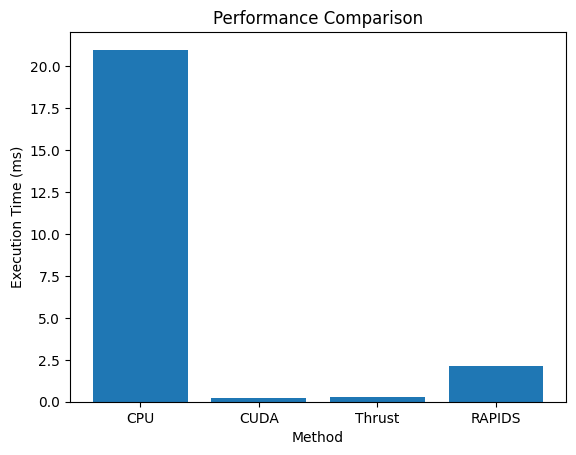

In [27]:
import matplotlib.pyplot as plt

methods = ["CPU", "CUDA", "Thrust", "RAPIDS"]
times = [21, 0.2, 0.3, 2.13]  # replace with your actual results

plt.figure()
plt.bar(methods, times)
plt.title("Performance Comparison")
plt.xlabel("Method")
plt.ylabel("Execution Time (ms)")
plt.show()


### Conclusion

GPU-based methods (CUDA, Thrust, RAPIDS) are significantly faster than CPU.

CPU executes sequentially O(N), while GPU executes in parallel O(N/P).

RAPIDS and Thrust provide highest performance with simplest implementation.

CUDA provides full control but requires more code.


# **Ques. 6. Write a CUDA C++ program using the Thrust library to compute the sum of all elements in a vector stored on the GPU. The vector is of size 10 and it should be initialized with values 1,…..10.**

Steps performed:

1. Create a host vector and initialize with values 1 to 10
2. Copy vector to GPU using thrust::device_vector
3. Compute sum using thrust::reduce()
4. Display result

In [28]:
%%writefile thrust_sum_vector.cu

#include <stdio.h>
#include <thrust/host_vector.h>
#include <thrust/device_vector.h>
#include <thrust/reduce.h>

#define N 10

int main()
{
    // Step 1: Create host vector
    thrust::host_vector<int> h_vec(N);

    // Step 2: Initialize values 1 to 10
    for(int i = 0; i < N; i++)
    {
        h_vec[i] = i + 1;
    }

    // Step 3: Copy to device vector (GPU)
    thrust::device_vector<int> d_vec = h_vec;

    // Step 4: Compute sum using thrust::reduce
    int sum = thrust::reduce(d_vec.begin(), d_vec.end(), 0, thrust::plus<int>());

    // Step 5: Print vector elements
    printf("Vector elements:\n");

    for(int i = 0; i < N; i++)
    {
        printf("%d ", h_vec[i]);
    }

    printf("\n");

    // Step 6: Print sum
    printf("Sum of elements using Thrust (GPU) = %d\n", sum);

    return 0;
}


Writing thrust_sum_vector.cu


In [29]:
!nvcc -arch=sm_75 thrust_sum_vector.cu -o thrust_sum_vector
!./thrust_sum_vector


Vector elements:
1 2 3 4 5 6 7 8 9 10 
Sum of elements using Thrust (GPU) = 55


#**7. Write a CUDA C++ program using Thrust to sort (ascending) a vector of integers on the GPU. Consider vector size 8 with following values: 7, 2, 9,1,5, 3, 8, 4. Print the vector before and afer sorting.**

Steps performed:

1. Create host vector and initialize with given values
2. Copy vector to GPU using thrust::device_vector
3. Sort vector using thrust::sort()
4. Copy sorted vector back to host
5. Print vector before and after sorting

In [30]:
%%writefile thrust_sort_vector.cu

#include <stdio.h>
#include <thrust/host_vector.h>
#include <thrust/device_vector.h>
#include <thrust/sort.h>

#define N 8

int main()
{
    // Step 1: Create and initialize host vector
    thrust::host_vector<int> h_vec(N);

    h_vec[0] = 7;
    h_vec[1] = 2;
    h_vec[2] = 9;
    h_vec[3] = 1;
    h_vec[4] = 5;
    h_vec[5] = 3;
    h_vec[6] = 8;
    h_vec[7] = 4;

    // Print original vector
    printf("Vector before sorting:\n");

    for(int i = 0; i < N; i++)
    {
        printf("%d ", h_vec[i]);
    }

    printf("\n");

    // Step 2: Copy to GPU
    thrust::device_vector<int> d_vec = h_vec;

    // Step 3: Sort using Thrust on GPU
    thrust::sort(d_vec.begin(), d_vec.end());

    // Step 4: Copy back to host
    h_vec = d_vec;

    // Print sorted vector
    printf("Vector after sorting (ascending order):\n");

    for(int i = 0; i < N; i++)
    {
        printf("%d ", h_vec[i]);
    }

    printf("\n");

    return 0;
}


Writing thrust_sort_vector.cu


In [31]:
!nvcc -arch=sm_75 thrust_sort_vector.cu -o thrust_sort_vector
!./thrust_sort_vector


Vector before sorting:
7 2 9 1 5 3 8 4 
Vector after sorting (ascending order):
1 2 3 4 5 7 8 9 
